# ATP Tennis Match Prediction (2000-2024)
---
---

## 1. Introduzione e Obiettivi

L'obiettivo di questo progetto è sviluppare un modello di Machine Learning basato due modelli di allenamento in grado di predire il vincitore di una partita di tennis professionistico ATP.
Il tennis è uno sport caratterizzato da una forte componente stocastica, ma anche da pattern storici ben definiti come gerarchie di ranking, punteggio di ELO, adattamento alle superfici, scontri diretti.

I dati utilizzati provengono dal repository pubblico di Jeff Sackmann (https://github.com/JeffSackmann/tennis_atp/tree/master). Il dataset completo copre l'arco temporale 1968-2024. Per questo progetto abbiamo scelto di iniziare dall'anno 2000 per garantire una maggiore consistenza nella raccolta statistica (es. minuti giocati, ace, doppi falli) che negli anni precedenti era spesso frammentaria.

---
---

## 2. Data Ingestion & Merging
I dati grezzi sono suddivisi in file CSV annuali (un file per anno). Il primo passo della pipeline è l'aggregazione di questi file in un unico DataFrame Pandas cronologicamente ordinato.
Durante la fase di ingestionrecupero dei dati, abbiamo applicato i seguenti filtri per garantire una qualità alta del dato:
- Esclusione dei tornei "Futures": I dati relativi ai tornei minori (Futures) sono stati esclusi. Questi match presentano spesso statistiche incomplete o inaffidabili e introducono un elevato livello di rumore che potrebbe confondere il modello.
- Esclusione delle Qualificazioni: Sono stati considerati solo i match dei tabelloni principali del circuito ATP e Challenger.
- Parsing delle Date: La colonna tourney_date è stata convertita immediatamente in formato datetime per permettere il futuro split cronologico per il Training e il Testing evitando il Data Leakage temporale.

In [29]:
import pandas as pd
import numpy as np
import glob
import os
from collections import deque

Come prima cosa sono stati sono stati scaricati i dataset da GitHub e sono stati inseriti nella cartella 'datasets'
Una volta impostato il nome del file mergiato, viene creato un dataframe temporaneo contenente tutti i dataset annuali in cui le date dei match sono state convertite nel formato datetime

In [30]:
INPUT_FOLDER = "datasets"
OUTPUT_FILENAME = "atp_matches_2000_2024_raw.csv"

print("--- UNIONE DATI ---")
    
    # Cerca file che iniziano con "atp_matches_" dentro la cartella datasets
pattern = os.path.join(INPUT_FOLDER, "atp_matches_*.csv")
all_files = glob.glob(pattern)
    

li = []
for filename in all_files:
    try:
        df_temp = pd.read_csv(filename, index_col=None, header=0)
            
        # Convertiamo subito la data (formato YYYYMMDD) in oggetto datetime
        df_temp['tourney_date'] = pd.to_datetime(df_temp['tourney_date'], format='%Y%m%d', errors='coerce')
            
        li.append(df_temp)
    except Exception as e:
        print(f"Errore caricamento {filename}: {e}")

if not li:
    print("Errore: Nessun file caricato.")
    
print("--- UNIONE COMPLETATA ---")

--- UNIONE DATI ---
--- UNIONE COMPLETATA ---


Per scrupolo il dataset viene ordinato secondo 'tourney_date' per rispettare esattamente la realtà temporale. Questo passaggioo è fondamentale perchè L'algoritmo ELO (che calcoleremo successivamente) è calcolato ricorsivamente: il punteggio di un giocatore oggi dipende dal risultato di ieri.
Ordiniamo prima per Data (tourney_date). A parità di data (es. tutti i match del primo turno di Wimbledon), usiamo l'ID del torneo e il numero del match (match_num) per mantenere la sequenza logica del tabellone.

Infine salviamo il risultato in un nuovo file CSV (atp_matches_2000_2024_raw.csv)

In [31]:
# Unione
df_total = pd.concat(li, axis=0, ignore_index=True)

# Ordinamento CRONOLOGICO (Fondamentale per l'ELO, anche se dovrebbero già essere ordinati)
df_total = df_total.sort_values(by=['tourney_date', 'tourney_id', 'match_num']).reset_index(drop=True)

#Salvo il dataset intero
df_total.to_csv(OUTPUT_FILENAME, index=False)
print(f"--- COMPLETATO ---")
print(f"File unito salvato come: {OUTPUT_FILENAME}")
print(f"Totale partite: {len(df_total)}")
print(df_total[['tourney_date', 'winner_name', 'loser_name']].head())

df_total.head()

--- COMPLETATO ---
File unito salvato come: atp_matches_2000_2024_raw.csv
Totale partite: 74906
  tourney_date          winner_name        loser_name
0   2000-01-03       Thomas Enqvist    Arnaud Clement
1   2000-01-03        Roger Federer  Jens Knippschild
2   2000-01-03  Jan Michael Gambill     Wayne Arthurs
3   2000-01-03   Sebastien Grosjean       Andrew Ilie
4   2000-01-03        Magnus Norman      Scott Draper


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2000-339,Adelaide,Hard,32,A,2000-01-03,1,102358,1.0,NaN,...,37.0,25.0,13.0,9.0,2.0,4.0,4.0,2606.0,56.0,805.0
1,2000-339,Adelaide,Hard,32,A,2000-01-03,2,103819,NaN,NaN,...,15.0,13.0,12.0,8.0,0.0,3.0,64.0,749.0,91.0,525.0
2,2000-339,Adelaide,Hard,32,A,2000-01-03,3,102998,NaN,NaN,...,59.0,49.0,22.0,16.0,4.0,5.0,58.0,803.0,105.0,449.0
3,2000-339,Adelaide,Hard,32,A,2000-01-03,4,103206,7.0,NaN,...,22.0,12.0,8.0,8.0,1.0,6.0,27.0,1298.0,54.0,845.0
4,2000-339,Adelaide,Hard,32,A,2000-01-03,5,102796,3.0,NaN,...,40.0,25.0,16.0,10.0,7.0,10.0,15.0,1748.0,154.0,297.0


---
---


## 3. Data Cleaning e Strategie di Imputazione
Analizzando il dataset abbiamo notato la presenza di valori mancanti (NaN) in diverse colonne chiave. Poichè non è possibile semplicemente rimuovere le righe con dati mancanti (che costituirebbero una perdita significativa di informazioni), né riempirle ciecamente con la media. Abbiamo quindi adottato strategie di imputazione differenziate basate sulla natura del dato.

1) Imputazione basata su Domain Knowledge (Seeds e Entry):
Nel tennis, se un giocatore non ha una "Testa di Serie" (seed), non è un dato mancante per errore: significa semplicemente che non è tra i favoriti (top 32).La strategia è quella di riempire i NaN con il valore 100 così che il modello numerico capisca che una testa di serie "Mancante" vale meno di una testa di serie n. 1 o n. 32. Il numero 100 agisce come un valore alto fittizio.
Similmente, per l'entry (tipo di ingresso al torneo), i valori vuoti indicano ingressi standard (STD).

2) Imputazione con Valori Sentinella (Ranking):
I giocatori senza ranking (spesso a inizio carriera) vengono riempiti con un ranking fittizio basso (2000) e punti 0. Questo permette al modello di trattarli come "giocatori di bassa classifica" senza dover scartare la partita.

3) Imputazione Statistica (Dati Fisici):
Per Età e Altezza, la mancanza del dato è data da una registrazione del valore non effattuata. Abbiamo deciso di utilizzare la media del dataset per età e altezza.
Per la Mano dominante, utilizziamo la moda, ovvero 'R' (Right-handed), dato che i mancini sono una minoranza statistica.

4) Gestione Statistiche Tecniche:
Per le statistiche del match (Ace, Doppi Falli, Punti Vinti), i valori mancanti sono critici. Abbiamo quindi deciso di riempirli con -1 (valore impossibile nel tennis).In questo modo queste colonne non verranno usate direttamente per la predizione, ma serviranno per calcolare le medie storiche. Il valore -1 servirà da "flag" per riconoscere alle quali partite ignorare nel calcolo della media ace, poichè i dati non sono completi

In [32]:
INPUT_FILE = "atp_matches_2000_2024_raw.csv"
OUTPUT_FILE = "atp_matches_2000_2024_cleaned.csv"

def clean_data(df):
    print(f"Righe originali: {len(df)}")
    
    # 1. GESTIONE TESTE DI SERIE (SEED)
    # Se vuoto, non è testa di serie,quindi mettiamo un valore alto (es. 100, signifia che è il 100esimo favorito alla vittoria del torneo)
    # così il modello capisce che vale meno della testa di serie n. 32
    df['winner_seed'] = df['winner_seed'].fillna(100)
    df['loser_seed'] = df['loser_seed'].fillna(100)
    
    # 2. GESTIONE ENTRY (WC, Q, etc.)
    # Se vuoto, è un ingresso Standard ('STD')
    df['winner_entry'] = df['winner_entry'].fillna('STD')
    df['loser_entry'] = df['loser_entry'].fillna('STD')
    
    # 3. GESTIONE RANKING
    # Se vuoto, assumiamo sia un ranking basso (es. 2000) non dovrebbero esserci player con rank o punti vuoti
    df['winner_rank'] = df['winner_rank'].fillna(2000)
    df['loser_rank'] = df['loser_rank'].fillna(2000)
    df['winner_rank_points'] = df['winner_rank_points'].fillna(0)
    df['loser_rank_points'] = df['loser_rank_points'].fillna(0)
    
    # 4. GESTIONE DATI FISICI (Altezza, Età) -> MEDIA
    # Calcoliamo la media globale per riempire gli attributi vuoti
    avg_age_w = df['winner_age'].mean()
    avg_age_l = df['loser_age'].mean()
    avg_ht_w = df['winner_ht'].mean()
    avg_ht_l = df['loser_ht'].mean()
    
    df['winner_age'] = df['winner_age'].fillna(avg_age_w)
    df['loser_age'] = df['loser_age'].fillna(avg_age_l)
    df['winner_ht'] = df['winner_ht'].fillna(avg_ht_w)
    df['loser_ht'] = df['loser_ht'].fillna(avg_ht_l)
    
    # Gestione mano (Destra/Sinistra), visto che la maggior parte è destra, riempiamo con 'R'
    df['winner_hand'] = df['winner_hand'].fillna('R')
    df['loser_hand'] = df['loser_hand'].fillna('R')
    
    # 5. GESTIONE SURFACE (Superficie)
    # Se mancano poche righe, meglio rimuoverle (non dovrebbe essere un dato mancante)
    df = df.dropna(subset=['surface']).copy()
    
    # 6. GESTIONE STATISTICHE MATCH (Ace, DF, Minuti...)
    # Riempiamo con -1 perchè questi dati non saranno input diretto (non posso sapere a priori le statistiche di un match futuro)
    # ma se calcoliamo le medie storiche dobbiamo ricordarci di toglierli controllare solo i valori >=0
    # Per 'minutes' usiamo la media di tutte le partite
    stats_cols = [
        'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 
        'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 
        'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced'
    ]
    
    for col in stats_cols:
        # Se è 'minutes' usiamo la media, per gli altri (conteggi) usiamo 0
        if col == 'minutes':
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(-1)
            
    print(f"Righe dopo pulizia: {len(df)}")
    
    # Verifica finale
    missing = df.isnull().sum().sum()
    print(f"Valori mancanti residui: {missing}")
    
    return df

print("--- INIZIO PULIZIA DATI ---")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"File {INPUT_FILE} non trovato!")

df_clean = clean_data(df)
    
df_clean.to_csv(OUTPUT_FILE, index=False)
print(f"Dataset pulito salvato come: {OUTPUT_FILE}")

--- INIZIO PULIZIA DATI ---
Righe originali: 74906
Righe dopo pulizia: 74853
Valori mancanti residui: 0
Dataset pulito salvato come: atp_matches_2000_2024_cleaned.csv


---
---

# 4 Feature Engineering
In questa fase trasformiamo i dati grezzi in indicatori predittivi. L'obiettivo è arricchire il dataset con informazioni che catturino:
- Forza Relativa tramite l'ELO
- Stato di forma tramite il momentum di vittorie
- Trend di crescita tramite i gradient
- Esperienza e scontri su varie superfici

In [33]:
INPUT_FILE_MATCHES = "atp_matches_2000_2024_cleaned.csv"
INPUT_FILE_RANK_90 = "atp_rankings_90s.csv" 
OUTPUT_FILE_ML = "dataset_ml_ready.csv"
OUTPUT_FILE_READABLE = "dataset_enriched.csv"

---

### 4.1 Funzioni di Supporto
Uno dei problemi principali dei sistemi ELO è l'avvio (Cold Start). Se iniziassimo l'analisi nel Gennaio 2000 assegnando a tutti i giocatori un punteggio standard di 1500, il modello impiegherebbe anni per allinearsi alla realtà, trattando leggende come Andre Agassi (allora N.1) come esordienti.

Per mitigare questo problema, utilizziamo la funzione load_initial_rankings, che attinge allo storico dei ranking anni '90 per generare una "fotografia" dello stato dell'arte al 31 Dicembre 1999.

Poiché il ranking ATP è lineare (1, 2, 3...) ma la differenza di abilità non lo è (il divario tra il N.1 e il N.10 è molto più ampio di quello tra il N.100 e il N.110), utilizziamo una scala logaritmica per convertire la posizione in classifica in un punteggio ELO iniziale:
$$ELO_{init} = 2500 - 300 \cdot \log_{10}(\text{Rank})$$

- Abbiamo impostato un Safety Floor a 1400 punti per evitare valori eccessivamente bassi per i giocatori di bassa classifica.

Per far funzionare correttamente il K-Factor Dinamico (spiegato in dettaglio più avanti), il sistema deve sapere se un giocatore è un veterano o un novellino. Poiché non abbiamo il conteggio esatto delle partite giocate prima del 2000, lo stimiamo basandoci sul ranking:

- Top 10: 500 partite
- Top 50: 300 partite
- Top 100: 150 partite
- top 500: 50 partite
- tutti gli altri 10

In [34]:
def load_initial_rankings(rank_file):
    print(f"--- Caricamento Ranking Iniziale da {rank_file} ---")
    try:
        df_rank = pd.read_csv(rank_file)
        last_date = df_rank['ranking_date'].max()
        df_init = df_rank[df_rank['ranking_date'] == last_date].copy()
        
        initial_elo_dict = {}
        initial_matches_dict = {}
        
        for _, row in df_init.iterrows():
            pid = row['player']
            rank = row['rank']
            if rank < 1: rank = 1
            elo_val = 2500 - 300 * np.log10(rank)
            if elo_val < 1400: elo_val = 1400
            initial_elo_dict[pid] = elo_val
            
            if rank <= 10: est_matches = 500
            elif rank <= 50: est_matches = 300
            elif rank <= 100: est_matches = 150
            elif rank <= 500: est_matches = 50
            else: est_matches = 10  
            initial_matches_dict[pid] = est_matches
            
        print(f"Inizializzati {len(initial_elo_dict)} giocatori.") 
        return initial_elo_dict, initial_matches_dict
    except Exception as e:
        print(f"ATTENZIONE: Impossibile caricare ranking ({e}).")
        return {}, {}

Un fattore determinante per l'accuratezza del sistema ELO è il K-factor, la costante che stabilisce la velocità con cui il punteggio di un giocatore reagisce ai nuovi risultati.Dopo una fase di sperimentazione iniziale con formule continue, abbiamo optato per un approccio "Tiered" (a scaglioni), simile a quello utilizzato negli scacchi agonistici. Questa scelta è stata dettata dalla necessità di mantenere il sistema reattivo anche per i veterani con migliaia di partite (es. Djokovic), evitando che il loro ELO diventasse troppo "inerziale" o statico.Il valore base del K-Factor ($K_{base}$) viene assegnato in base all'esperienza del giocatore (numero di partite giocate, $M$), seguendo tre fasce di stabilità:$$K_{base} =
\begin{cases}
50 & \text{se } M < 30 \quad (\text{Esordienti: Alta Volatilità}) \\
40 & \text{se } 30 \le M < 100 \quad (\text{Emergenti: Media Volatilità}) \\
32 & \text{se } M \ge 100 \quad (\text{Veterani: Stabilità Reattiva})
\end{cases}$$Esordienti ($K=50$): Permette al sistema di calibrare molto rapidamente il livello reale di un nuovo talento.Veterani ($K=32$): Assicura stabilità, ma mantiene un valore sufficientemente alto (standard competitivo) per penalizzare significativamente anche i campioni in caso di sconfitte inattese.Ponderazione per Importanza del TorneoIn aggiunta all'esperienza, abbiamo raffinato il modello applicando dei moltiplicatori ($K_{mult}$) basati sul prestigio del torneo. L'assunto è che nei tornei maggiori la motivazione e l'impegno siano massimi, rendendo il risultato più veritiero rispetto ai tornei minori.La formula finale è:

$K = K_{base} \cdot K_{mult}$

con i seguenti coefficienti:

Grand Slam: $K_{mult} = 1.1$ 

Masters 1000 e ATP Finals: $K_{mult} = 1.05$

ATP 250 / 500 / Challenger: $K_{mult} = 1.0$

In [35]:
def get_k_factor_538(matches_count, tourney_level):
    if matches_count < 30:
        k_base = 50  # ROOKIE: Oscillazioni enormi per capire subito quanto vale
    elif matches_count < 100:
        k_base = 40  # EMERGENTE: Ancora molto reattivo
    else:
        k_base = 32  # VETERANO: Stabilizziamo a 32 (Standard scacchistico)
        
    if tourney_level == 'G': multiplier = 1.1
    elif tourney_level == 'M' or tourney_level == 'F': multiplier = 1.05
    else: multiplier = 1.0
    
    return k_base * multiplier

---

### 4.2 Matematica dell'ELO
Un primo attributo che ci è sembrato necessario inserire è l'ELO, questo attributo assegna un punteggio di forza relativo ad ogni giocatore che, a differenza del ranking ATP (si basa i punti dell'anno precedente), l'ELO è un sistema che si aggiorna partita dopo partita.
Ogni giocatore sconosciuto inizia la sua carriera con un rating ELO di 1500 e questo valore (che chiameremo R) si aggiorna dopo ogni partita giocata, l'aggiornamento segue questa regola:
$$R_{new} =R + K \cdot (S - E)$$

In questa formula è presente la variabile S che indica il risultato della partita (S=1 se il giocatore ha vinto, S=0 se il giocatore ha perso), è inoltre presente la variabile E che indica l'aspettativa di vittoria del giocatore A in quella partita contro il giocatore B ed è calcolata in questo modo:
$$E_A = \frac{1}{1 + 10^{(R_{mix}^B - R_{mix}^A) / 400}}$$

Il denominatore 400 definisce la "Larghezza" della curva ovvero stabilisce quanta differenza di punti serve per avere una certa probabilità di vittoria. Con una differenza di 400 punti un giocatore ha una probabilità del 91% di vincere la partita

Un dettaglio importante da notare è che utilizziamo $R_{mix}& per indicare il rating ELO per ogni giocatore perchè per ogni match, calcoliamo un rating misto che combina l'ELO Generale ($R_{overall}$) e quello di Superficie ($R_{surface}$), questo per riflettere lla dominanza di alcuni giocatori su certe superfici di gioco:

$$R_{mix} = 0.6 \cdot R_{overall} + 0.4 \cdot R_{surface}$$

---

### 4.3 Simulazione Storica
La funzione calculate_features agisce come una simulazione cronologica che ripercorre l'intera storia del tennis dal 2000 al 2024, partita dopo partita.

L'algoritmo segue un rigoroso processo a 3 Fasi per ogni singola riga del dataset, eliminando tutte quelle features che rappresentano un data leakage.

**Fase 1: Inizializzazione e Memoria**
Prima di avviare il ciclo cronologico, è fondamentale inizializzare correttamente le strutture dati che terranno traccia dello stato del sistema.
- elo_overall: Dizionario che mantiene il punteggio ELO corrente. Inizializzato con i valori storici (o 1500 per i nuovi).
- elo_surface: Dizionario per tracciare l'ELO specifico per ogni superficie (Hard, Clay, Grass, Carpet).
- matches_played: Contatore necessario per calcolare il K-Factor Dinamico.
- win_history: Una coda (deque) per ogni giocatore che memorizza gli ultimi risultati (1 o 0). Serve per calcolare la Forma.
- elo_history: Traccia l'evoluzione dell'ELO nel tempo per calcolare il Gradiente (Trend di crescita).
- feats: Un dizionario di liste vuote. Invece di scrivere riga per riga nel DataFrame (lento), accumuliamo qui i risultati e li uniamo solo alla fine.

**Fase 2: Funzioni ausiliarie**
All'interno del ciclo di calcolo, definiamo due funzioni ausiliarie per estrarre indicatori dinamici dalla memoria storica. Queste funzioni implementano il concetto di "Rolling Window".

- get_win_pct(pid, n) - La Forma: Calcola la percentuale di vittorie nelle ultime $n$ partite. Un giocatore che ha vinto l'80% delle ultime 5 partite (w_win_last_5 = 0.8) è probabilmente in uno stato di fiducia mentale superiore rispetto a uno con lo stesso ELO ma che ne ha vinto solo il 20%.

- get_elo_gradient(pid, n) - Il Trend: Misura la variazione netta di punteggio ELO negli ultimi $n$ match.
$$Gradient = ELO_{t} - ELO_{t-n}$$
Serve a distinguere la traiettoria della carriera.Gradiente Positivo (+50): Il giocatore sta migliorando rapidamente (es. un giovane in ascesa).Gradiente Negativo (-50): Il giocatore sta peggiorando (es. rientro da infortunio o declino fisico).Gradiente Nullo (~0): Le prestazioni sono stabili (es. un giocatore esperto).

**Fase 3: Ciclo Principale**
Il cuore dell'algoritmo è un ciclo iterativo che processa le partite in rigoroso ordine cronologico. Per ogni riga del dataset, il sistema esegue quattro operazioni sequenziali:

1. Gestione Dinamica dei Nuovi Giocatori: Non tutti i giocatori sono presenti dal 2000. Quando un "nuovo" giocatore (es. Carlos Alcaraz nel 2020) appare per la prima volta, il sistema lo rileva e lo inizializza
2. Snapshot Pre-Match: Salviamo i dati (ELO, H2H, Forma, ...) nelle liste di output PRIMA di elaborare il risultato della partita corrente
3. Calcolo delle Rolling Features: Invochiamo le funzioni ausiliarie get_win_pct e get_elo_gradient su diverse finestre temporali (5, 25, 50 partite) per catturare sia la forma a breve termine che i trend a lungo termine.
4. Aggiornamento Post-Match: Una volta salvati i dati per il training, il sistema "osserva" il risultato reale, calcola la probabilità attesa e aggiorna l'ELO dei due giocatori, incrementa il contatore delle partite e aggiorna la memoria storica, influenzando così il K-Factor e le statistiche per il match successivo.

In [36]:
def calculate_features(df, initial_elos, initial_matches):
    print("Calcolo ELO, H2H e Feature Avanzate (Gradienti, Form)...")
    
    '''
    FASE 1: INIZIALIZZAZZIONE E MEMORIA
    '''
    elo_overall = initial_elos.copy()
    elo_surface = {'Hard': initial_elos.copy(), 'Clay': initial_elos.copy(), 
                   'Grass': initial_elos.copy(), 'Carpet': initial_elos.copy()}
    matches_played = initial_matches.copy()
    h2h_history = {} 

   
    win_history = {} 
    elo_history = {} 

    feats = {
        'w_elo': [], 'l_elo': [], 'w_surface_elo': [], 'l_surface_elo': [],
        'w_h2h': [], 'l_h2h': [], 'w_prob_elo': [],
        'w_win_last_5': [], 'l_win_last_5': [],
        'w_win_last_25': [], 'l_win_last_25': [],
        'w_win_last_50': [], 'l_win_last_50': [],
        'w_win_last_100': [], 'l_win_last_100': [],
        'w_elo_grad_20': [], 'l_elo_grad_20': [],
        'w_elo_grad_35': [], 'l_elo_grad_35': [],
        'w_elo_grad_50': [], 'l_elo_grad_50': [],
        'w_elo_grad_100': [], 'l_elo_grad_100': [],
        'w_matches_played': [], 'l_matches_played': []
    }

    '''
    FASE 2: FUNZIONI DI SUPPORTO
    '''
    def get_win_pct(pid, n):
        if pid not in win_history: return 0.0
        history = list(win_history[pid])
        if not history: return 0.0
        last_n = history[-n:] 
        return sum(last_n) / len(last_n)

    def get_elo_gradient(pid, n):
        if pid not in elo_history: return 0.0
        hist = list(elo_history[pid])
        if len(hist) < 2: return 0.0
        current_elo = hist[-1]
        past_elo = hist[-n] if len(hist) >= n else hist[0]
        return current_elo - past_elo

    '''
    FASE 3: CICLO PRINCIPALE
    '''
    for idx, row in df.iterrows():
        wid, lid = row['winner_id'], row['loser_id']
        level = row['tourney_level']
        surface = row['surface']
        
        # --- FASE 3.1: Inizializzazione Giocatori ---
        # GESTIONE VINCITORE
        if wid not in elo_history:
            win_history[wid] = deque(maxlen=100)
            elo_history[wid] = deque(maxlen=101)
            
            # Se non ha nemmeno l'ELO (Nuovo Giocatore)
            if wid not in elo_overall:
                r = row['winner_rank'] if row['winner_rank'] < 2000 else 500
                elo_val = max(1400, 2500 - 300 * np.log10(r) if r > 0 else 1500)
                elo_overall[wid] = elo_val
                matches_played[wid] = 0
                for s in elo_surface: elo_surface[s][wid] = elo_val
            
            # Importante: Aggiungiamo il valore iniziale alla storia!
            elo_history[wid].append(elo_overall[wid])

        # GESTIONE PERDENTE
        if lid not in elo_history:
            win_history[lid] = deque(maxlen=100)
            elo_history[lid] = deque(maxlen=101)
            
            if lid not in elo_overall:
                r = row['loser_rank'] if row['loser_rank'] < 2000 else 500
                elo_val = max(1400, 2100 - 300 * np.log10(r) if r > 0 else 1500)
                elo_overall[lid] = elo_val
                matches_played[lid] = 0
                for s in elo_surface: elo_surface[s][lid] = elo_val
            
            elo_history[lid].append(elo_overall[lid])

        # --- FASE 3.2: Calcolo Feature Pre-Match ---
        curr_w_elo = elo_overall[wid]
        curr_l_elo = elo_overall[lid]
        s_clean = surface if surface in elo_surface else 'Hard'
        curr_w_surf = elo_surface[s_clean].get(wid, curr_w_elo)
        curr_l_surf = elo_surface[s_clean].get(lid, curr_l_elo)
        
        pair_key = tuple(sorted((wid, lid)))
        if pair_key not in h2h_history: h2h_history[pair_key] = {wid: 0, lid: 0}
        
        feats['w_elo'].append(curr_w_elo)
        feats['l_elo'].append(curr_l_elo)
        feats['w_surface_elo'].append(curr_w_surf)
        feats['l_surface_elo'].append(curr_l_surf)
        feats['w_h2h'].append(h2h_history[pair_key][wid])
        feats['l_h2h'].append(h2h_history[pair_key][lid])
        feats['w_matches_played'].append(matches_played[wid])
        feats['l_matches_played'].append(matches_played[lid])

        # --- FASE 3.3: Calcolo Feature Rolling ---
        windows_win = [5, 25, 50, 100]
        windows_grad = [20, 35, 50, 100]
        
        for w in windows_win:
            feats[f'w_win_last_{w}'].append(get_win_pct(wid, w))
            feats[f'l_win_last_{w}'].append(get_win_pct(lid, w))
            
        for w in windows_grad:
            feats[f'w_elo_grad_{w}'].append(get_elo_gradient(wid, w))
            feats[f'l_elo_grad_{w}'].append(get_elo_gradient(lid, w))

        # --- FASE 3.4: Calcolo ELO Post-Match ---
        w_mix = 0.6 * curr_w_elo + 0.4 * curr_w_surf
        l_mix = 0.6 * curr_l_elo + 0.4 * curr_l_surf
        prob_w = 1 / (1 + 10 ** ((l_mix - w_mix) / 400))
        feats['w_prob_elo'].append(prob_w)
        
        k_w = get_k_factor_538(matches_played[wid], level)
        k_l = get_k_factor_538(matches_played[lid], level)
        delta_w = k_w * (1 - prob_w)
        delta_l = k_l * (0 - (1 - prob_w))
        
        elo_overall[wid] += delta_w
        elo_overall[lid] += delta_l
        elo_surface[s_clean][wid] += delta_w
        elo_surface[s_clean][lid] += delta_l
        matches_played[wid] += 1
        matches_played[lid] += 1
        h2h_history[pair_key][wid] += 1
        
        # Aggiornamento Storico
        win_history[wid].append(1)
        win_history[lid].append(0)
        elo_history[wid].append(elo_overall[wid])
        elo_history[lid].append(elo_overall[lid])

    for k, v in feats.items():
        df[k] = v
        
    return df

--- 

### 4.4 Preparazione finale per il Machine Learning
Il dataset prodotto finora ha una struttura rigida: ogni riga ha un winner_... e un loser_... Questo formato non è adatto all'addestramento di una Rete Neurale per due motivi:
- Data Leakage Implicito: Il modello capirebbe banalmente che il giocatore nelle colonne "Winner" è quello che vince.
- Mancanza di Generalizzazione: Vogliamo che il modello impari a valutare una sfida tra "Giocatore A" e "Giocatore B", indipendentemente dall'ordine.

La funzione transform_to_ml_format risolve questi problemi applicando tre trasformazioni:

**A. Encoding Variabili Categoriche**

Abbiamo trasformato le variabili categoriche utilizzando strategie diverse in base alla natura del dato:
- Superficie (One-Hot Encoding):Le superfici (Hard, Clay, Grass, Carpet) sono nominali: non esiste un ordine intrinseco.Abbiamo creato 4 colonne binarie indipendenti (es. surface_Clay: 1 se terra, 0 altrimenti). Questo permette al modello di identificare correttamente gli "specialisti" di ogni terreno.
- Turno del Torneo (Ordinal Encoding):A differenza della superficie, i turni possiedono una gerarchia chiara.Abbiamo mappato i turni su una scala numerica crescente (R128 = 1 $\rightarrow$ Finale = 7). In questo modo, il modello può interpretare matematicamente l'aumento progressivo della difficoltà e della tensione man mano che il torneo avanza.
- Mano (Binary Encoding):Dopo lo scambio casuale, convertiamo l'informazione sulla mano dominante ('L'/'R') in una variabile binaria is_left (1 se mancino, 0 se destro).

**B. Anonimizzazione e Random Swapping**
Trasformiamo le etichette Winner/Loser in Player 1 (P1) e Player 2 (P2). Successivamente, applichiamo un Random Swap sul 50% delle righe:
- Nel 50% dei casi: P1 è il Vincitore quindi il valore di Target sarà 1
- Nel 50% dei casi: P1 è il Perdente quindi il valore di Target sarà 0

Questo garantisce che le classi siano perfettamente bilanciate e che il modello non abbia bias posizionali.

**C. Feature Differenziali**
Le Reti Neurali apprendono molto più efficacemente dalle differenze relative che dai valori assoluti. Invece di fornire P1_ELO = 2000 e P2_ELO = 1900, forniamo:
$$\Delta ELO = P1_{ELO} - P2_{ELO} = +100$$

Calcoliamo le differenze per tutte le metriche chiave: DIFF_ELO, ATP_RANK_DIFF, WIN_LAST_X_DIFF, ELO_GRAD_X_DIFF, DIFF_N_GAMES, diff_age, diff_ht. 


In [37]:
def transform_to_ml_format(df):
    print("Trasformazione finale per ML (Random Swap, Diffs & Encoding)...")
    
    # SELEZIONE COLONNE
    cols_base = [
        'tourney_date', 'match_num', 'best_of', 
        'winner_id', 'winner_name', 'winner_rank', 'winner_rank_points', 'winner_age', 'winner_hand', 'winner_ht', 
        'loser_id', 'loser_name', 'loser_rank', 'loser_rank_points', 'loser_age', 'loser_hand', 'loser_ht'
    ]
    
    # Colonne categoriche da trasformare
    cat_cols = ['surface', 'round', 'tourney_level']
    
    # Feature calcolate
    calc_cols = [c for c in df.columns if c.startswith('w_') or c.startswith('l_')]
    
    # Uniamo tutto
    df_ml = df[cols_base + cat_cols + calc_cols].copy()
    
    # --- A. ENCODING VARIABILI CATEGORICHE ---
    
    # Superficie (One-Hot Encoding)
    df_ml['surface_Hard'] = (df_ml['surface'] == 'Hard').astype(int)
    df_ml['surface_Clay'] = (df_ml['surface'] == 'Clay').astype(int)
    df_ml['surface_Grass'] = (df_ml['surface'] == 'Grass').astype(int)
    df_ml['surface_Carpet'] = (df_ml['surface'] == 'Carpet').astype(int) 
    
    # Turno (Ordinal Encoding)
    round_map = {
        'R128': 1, 'RR': 1, 
        'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7
    }
    df_ml['round_num'] = df_ml['round'].map(round_map).fillna(1).astype(int)
    
    # Rimuoviamo le colonne originali stringa
    df_ml = df_ml.drop(columns=['surface', 'round', 'tourney_level'])

    # --- B. RINOMINA GENERICA (Winner -> P1, Loser -> P2) ---
    rename_map = {}
    for c in df_ml.columns:
        if c.startswith('winner') or c.startswith('w_'):
            rename_map[c] = c.replace('winner', 'p1').replace('w_', 'p1_')
        elif c.startswith('loser') or c.startswith('l_'):
            rename_map[c] = c.replace('loser', 'p2').replace('l_', 'p2_')
    df_ml = df_ml.rename(columns=rename_map)
    
    # Inizialmente P1 è sempre il vincitore
    df_ml['target'] = 1 
    
    # --- 4. RANDOM SWAP ---
    np.random.seed(42)
    mask = np.random.rand(len(df_ml)) < 0.5
    
    p1_cols = [c for c in df_ml.columns if 'p1' in c]
    for c1 in p1_cols:
        c2 = c1.replace('p1', 'p2')
        if c2 in df_ml.columns:
            df_ml.loc[mask, [c1, c2]] = df_ml.loc[mask, [c2, c1]].values
            
    df_ml.loc[mask, 'target'] = 0
    
    # --- 5. FEATURE ENGINEERING DIFFERENZIALE ---
    
    # Mano (Ora che abbiamo p1_hand e p2_hand scambiati correttamente)
    df_ml['p1_is_left'] = (df_ml['p1_hand'] == 'L').astype(int)
    df_ml['p2_is_left'] = (df_ml['p2_hand'] == 'L').astype(int)
    
    # Differenziali
    df_ml['ATP_RANK_DIFF'] = df_ml['p2_rank'] - df_ml['p1_rank'] 
    df_ml['ATP_POINT_DIFF'] = df_ml['p1_rank_points'] - df_ml['p2_rank_points']
    df_ml['DIFF_ELO'] = df_ml['p1_elo'] - df_ml['p2_elo']
    df_ml['DIFF_SURF_ELO'] = df_ml['p1_surface_elo'] - df_ml['p2_surface_elo']
    df_ml['DIFF_H2H'] = df_ml['p1_h2h'] - df_ml['p2_h2h']
    df_ml['DIFF_N_GAMES'] = df_ml['p1_matches_played'] - df_ml['p2_matches_played']
    
    for x in [5, 25, 50, 100]:
        c1, c2 = f'p1_win_last_{x}', f'p2_win_last_{x}'
        df_ml[f'WIN_LAST_{x}_DIFF'] = df_ml[c1] - df_ml[c2]
        
    for x in [20, 35, 50, 100]:
        c1, c2 = f'p1_elo_grad_{x}', f'p2_elo_grad_{x}'
        df_ml[f'ELO_GRAD_{x}_DIFF'] = df_ml[c1] - df_ml[c2]
        
    df_ml['diff_age'] = df_ml['p1_age'] - df_ml['p2_age']
    df_ml['diff_ht'] = df_ml['p1_ht'] - df_ml['p2_ht']
    
    return df_ml

---

### 4.5 Esecuzione della Pipeline
In quest'ultima fase, viene eseguito l'intero processo di elaborazione. Il flusso di lavoro segue 4 step sequenziali:

1. Inizializzazione: Carichiamo i ranking storici degli anni '90 per risolvere il problema del Cold Start e assegnare i valori iniziali di ELO ed esperienza.

2. Core Processing (La Simulazione): Eseguiamo calculate_features sul dataset completo. Questa operazione richiede tempo poiché ripercorre cronologicamente oltre 70.000 partite, aggiornando lo stato del sistema match dopo match.

3. Trasformazione ML: Convertiamo il dataset arricchito in un formato pronto per la Rete Neurale (Encoding, Random Swap, Differenziali).

4. Export dei Dati: Generiamo due file distinti:

- dataset_enriched.csv: Il file "leggibile" (con Winner/Loser), utile per l'analisi umana e il debugging.

- dataset_ml_ready.csv: Il file "anonimizzato" e numerico (P1/P2, Target 0/1), che sarà l'input effettivo per il training del modello.

In [38]:
print("--- ELABORAZIONE FEATURES ---")
init_elo, init_matches = load_initial_rankings(INPUT_FILE_RANK_90)
    
try:
    df = pd.read_csv(INPUT_FILE_MATCHES)
except FileNotFoundError:
    print(f"ERRORE: Non trovo {INPUT_FILE_MATCHES}.")


df_enriched = calculate_features(df, init_elo, init_matches)
df_enriched.to_csv(OUTPUT_FILE_READABLE, index=False)
print(f"File leggibile salvato: {OUTPUT_FILE_READABLE}")
    
df_ml = transform_to_ml_format(df_enriched)
df_ml = df_ml.fillna(0)
    
df_ml.to_csv(OUTPUT_FILE_ML, index=False)
print(f"Dataset ML Completo salvato: {OUTPUT_FILE_ML}")
print("Colonne generate:", [c for c in df_ml.columns if 'DIFF' in c])

--- ELABORAZIONE FEATURES ---
--- Caricamento Ranking Iniziale da atp_rankings_90s.csv ---
Inizializzati 1571 giocatori.
Calcolo ELO, H2H e Feature Avanzate (Gradienti, Form)...
File leggibile salvato: dataset_enriched.csv
Trasformazione finale per ML (Random Swap, Diffs & Encoding)...
Dataset ML Completo salvato: dataset_ml_ready.csv
Colonne generate: ['ATP_RANK_DIFF', 'ATP_POINT_DIFF', 'DIFF_ELO', 'DIFF_SURF_ELO', 'DIFF_H2H', 'DIFF_N_GAMES', 'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF', 'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF']


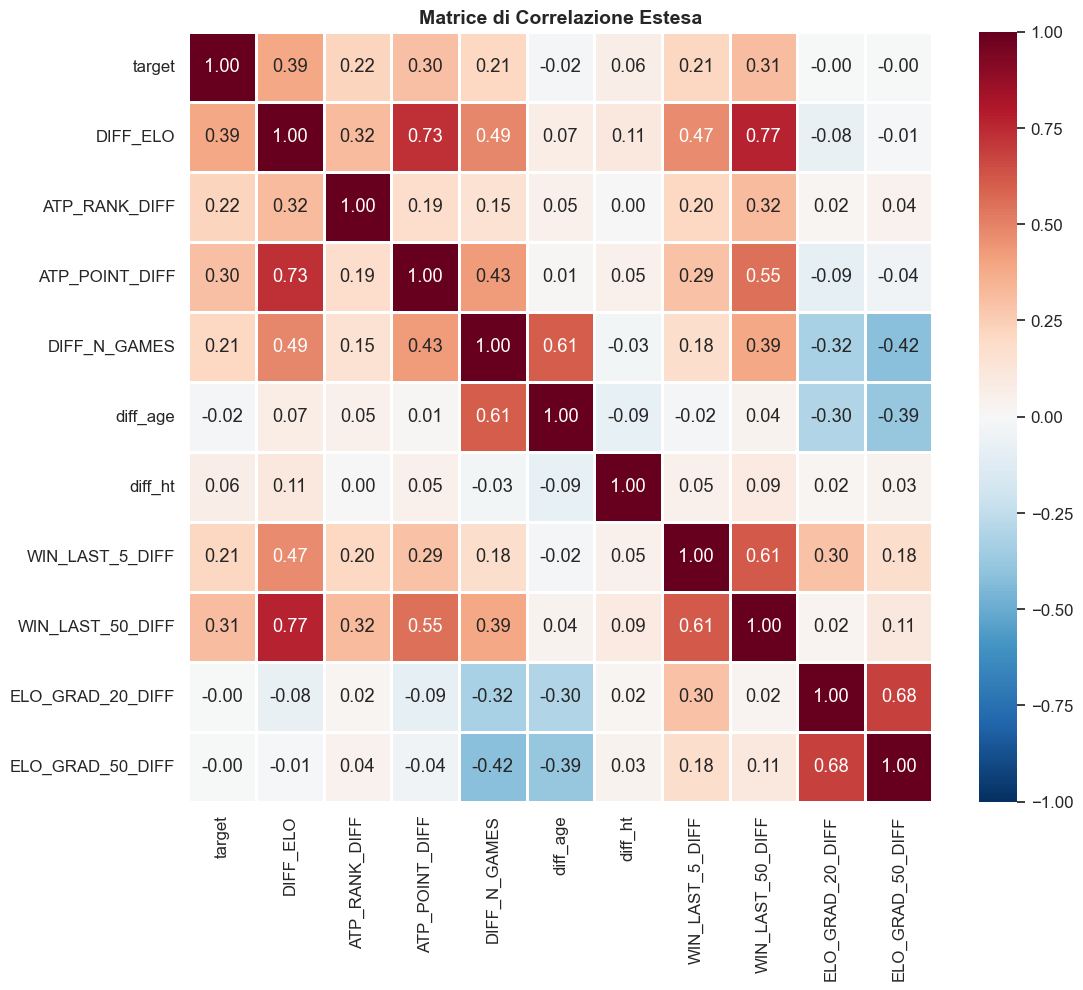

Giocatore: Jannik Sinner - Match trovati: 353
Giocatore: Carlos Alcaraz - Match trovati: 265
Giocatore: Novak Djokovic - Match trovati: 1363


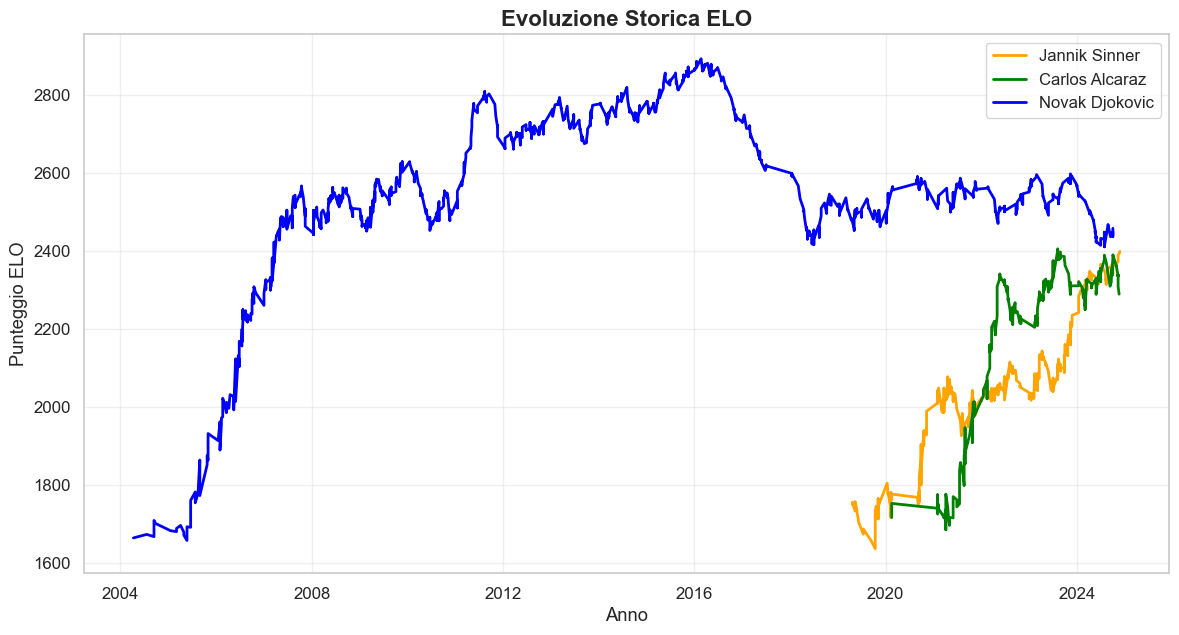

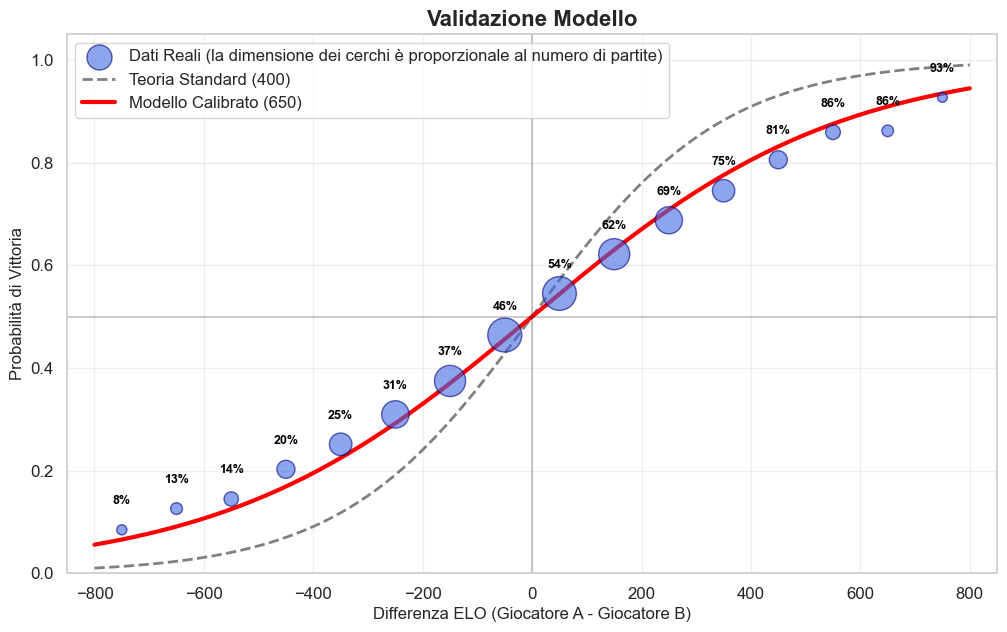

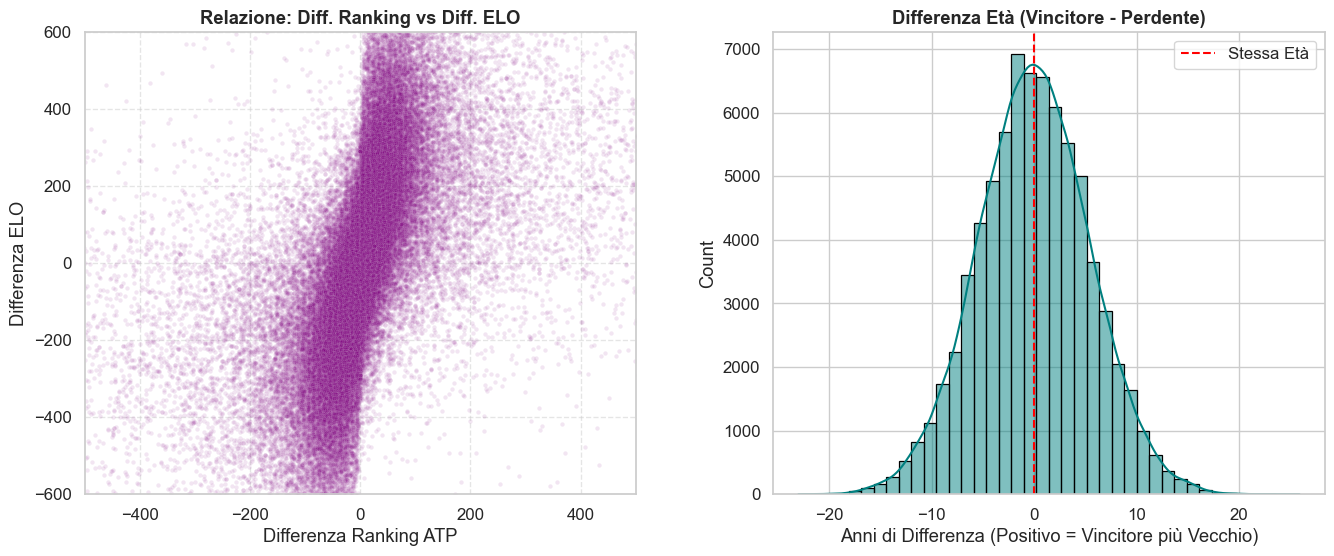

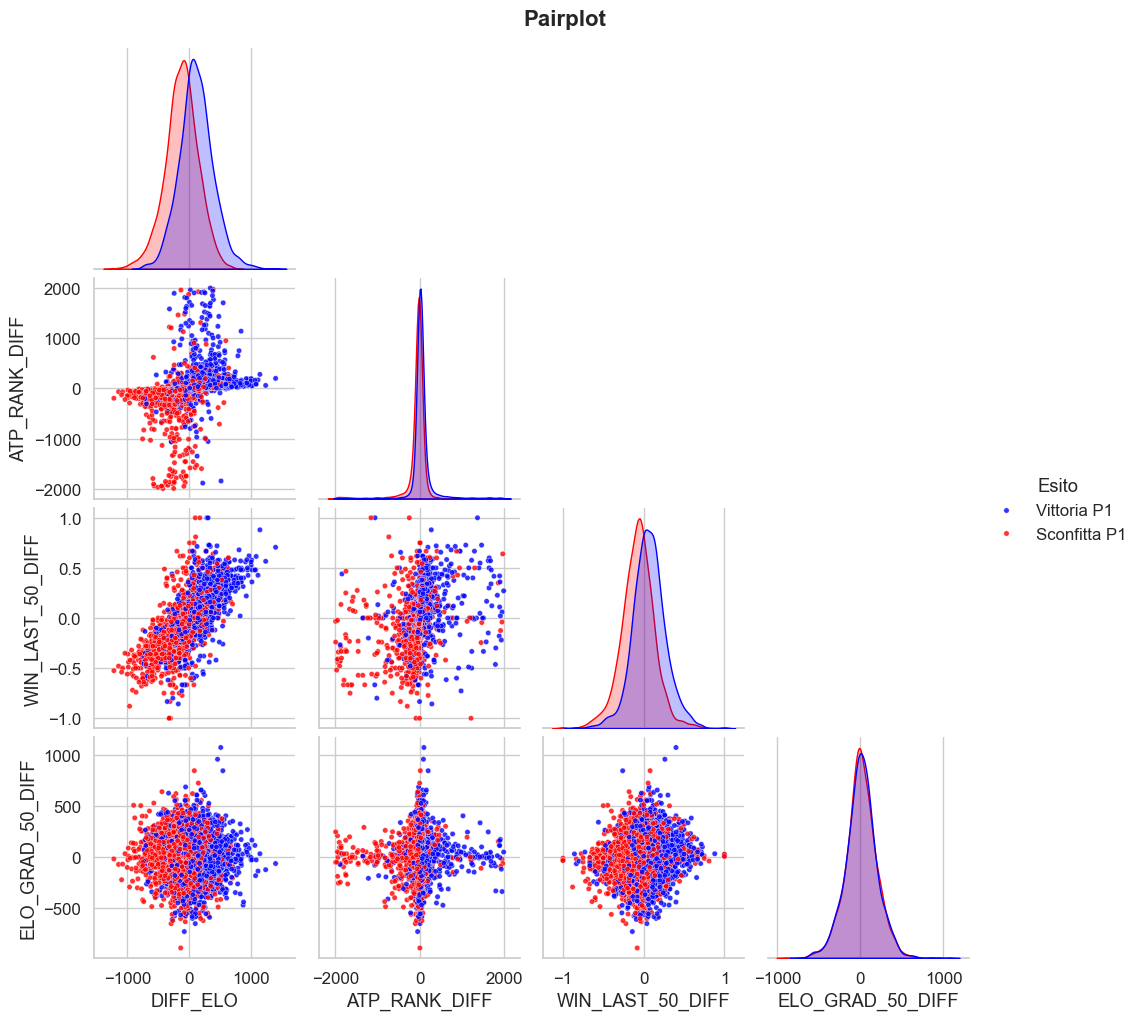

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  

# Configurazioni grafiche
sns.set_context("notebook", font_scale=1.1)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caricamento Dataset 
try:
    df_human = pd.read_csv("dataset_enriched.csv")
    df_ml = pd.read_csv("dataset_ml_ready.csv")
except FileNotFoundError:
    print("ERRORE: File csv non trovati. Esegui prima le celle precedenti!")

# ==========================================
# 1. MATRICE DI CORRELAZIONE ESTESA
# ==========================================

extended_feats = [
    'target', 
    'DIFF_ELO',          # La regina
    'ATP_RANK_DIFF',     # Classifica ufficiale
    'ATP_POINT_DIFF',    # Punti ATP (più preciso del rank)
    'DIFF_N_GAMES',      # Esperienza (Veterano vs Novellino)
    'diff_age',          # Gioventù vs Esperienza
    'diff_ht',           # Altezza 
    'WIN_LAST_5_DIFF',   # Forma Breve
    'WIN_LAST_50_DIFF',  # Forma Lunga
    'ELO_GRAD_20_DIFF',  # Trend Breve
    'ELO_GRAD_50_DIFF'   # Trend Lungo
]


corr_matrix = df_ml[extended_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, linewidths=1)
plt.title("Matrice di Correlazione Estesa", fontsize=14, fontweight='bold')
plt.show()

# ==========================================
# 2. ELO EVOLUTION: SINNER vs ALCARAZ vs DJOKOVIC
# ==========================================

target_players = ["Jannik Sinner", "Carlos Alcaraz", "Novak Djokovic"]
colors = {"Jannik Sinner": "orange", "Carlos Alcaraz": "green", "Novak Djokovic": "blue"}

plt.figure(figsize=(14, 7))

found_data = False 

for player in target_players:
    # Cerchiamo il giocatore sia come vincitore che come perdente
    w_mask = df_human['winner_name'].str.contains(player, case=False, na=False)
    l_mask = df_human['loser_name'].str.contains(player, case=False, na=False)
    
    # Estraiamo Data e ELO
    w_data = df_human.loc[w_mask, ['tourney_date', 'w_elo']].rename(columns={'w_elo': 'elo'})
    l_data = df_human.loc[l_mask, ['tourney_date', 'l_elo']].rename(columns={'l_elo': 'elo'})
    
    # Uniamo tutto
    player_history = pd.concat([w_data, l_data])
    
    player_history['date'] = pd.to_datetime(player_history['tourney_date'], errors='coerce')
    
    # Ordiniamo cronologicamente
    player_history = player_history.sort_values('date').dropna()
    
    print(f"Giocatore: {player} - Match trovati: {len(player_history)}")
    
    if not player_history.empty:
        found_data = True
        plt.plot(player_history['date'], player_history['elo'], 
                 label=player, color=colors.get(player, 'gray'), linewidth=2)

if found_data:
    plt.title("Evoluzione Storica ELO", fontsize=16, fontweight='bold')
    plt.ylabel("Punteggio ELO")
    plt.xlabel("Anno")
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("ATTENZIONE: Nessun dato trovato per i giocatori selezionati. Controlla i nomi nel CSV.")

# ==========================================
# 3. VALIDAZIONE DEL MODELLO
# ==========================================

# Creiamo intervalli di ELO
bins = list(range(-800, 801, 100)) 
df_ml['elo_bin'] = pd.cut(df_ml['DIFF_ELO'], bins=bins)

# Calcoliamo Statistiche
calibration = df_ml.groupby('elo_bin', observed=False)['target'].agg(['mean', 'count']).reset_index()
calibration.rename(columns={'mean': 'target'}, inplace=True) 
calibration['mid_point'] = calibration['elo_bin'].apply(lambda x: x.mid).astype(float)

# Calcoliamo Curve Teoriche
x_theoretical = np.linspace(-800, 800, 200)
y_std = 1 / (1 + 10 ** (-x_theoretical / 400))
best_scale = 650
y_calibrated = 1 / (1 + 10 ** (-x_theoretical / best_scale))

# --- PLOT ---
plt.figure(figsize=(12, 7))

# DISEGNIAMO I DATI REALI 
# Calcolo dimensioni proporzionali (min 50, max 600)
# Normalizziamo i conteggi tra 0 e 1 per scalare i pallini
counts = calibration['count']
min_s, max_s = 50, 600
if counts.max() > counts.min():
    sizes = (counts - counts.min()) / (counts.max() - counts.min()) * (max_s - min_s) + min_s
else:
    sizes = 300 # Dimensione fissa se tutti i bin sono uguali

plt.scatter(
    calibration['mid_point'], calibration['target'], 
    s=sizes,  # Usiamo le dimensioni calcolate
    color='royalblue', alpha=0.6, 
    label='Dati Reali (la dimensione dei cerchi è proporzionale al numero di partite)', 
    zorder=5,
    edgecolor='navy' 
)

#DISEGNIAMO LE CURVE
plt.plot(x_theoretical, y_std, color='gray', linestyle='--', linewidth=2, label='Teoria Standard (400)')
plt.plot(x_theoretical, y_calibrated, color='red', linewidth=3, label=f'Modello Calibrato ({best_scale})')

# Decorazioni
plt.title(f"Validazione Modello", fontsize=16, fontweight='bold')
plt.xlabel("Differenza ELO (Giocatore A - Giocatore B)", fontsize=12)
plt.ylabel("Probabilità di Vittoria", fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.ylim(0, 1.05)
plt.xlim(-850, 850)
plt.grid(True, alpha=0.3)
plt.axhline(0.5, linestyle='-', color='black', alpha=0.2)
plt.axvline(0, linestyle='-', color='black', alpha=0.2)

# Etichette percentuali
for line in range(0, calibration.shape[0]):
    mid = calibration.mid_point[line]
    val = calibration.target[line]
    count = calibration['count'][line]
    if count > 50 and not np.isnan(val): 
        plt.text(mid, val + 0.05, f"{val*100:.0f}%", horizontalalignment='center', color='black', fontsize=9, fontweight='bold')

plt.show()

# ==========================================
# 4. MULTI-PLOT ESPLORATIVO 
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
plt.subplots_adjust(wspace=0.25) # Spazio orizzontale

# --- GRAFICO A: ELO vs RANKING ---
sns.scatterplot(x='ATP_RANK_DIFF', y='DIFF_ELO', data=df_ml, 
                alpha=0.1, ax=axes[0], color='purple', s=10)
axes[0].set_title("Relazione: Diff. Ranking vs Diff. ELO", fontweight='bold')
axes[0].set_xlabel("Differenza Ranking ATP")
axes[0].set_ylabel("Differenza ELO")
axes[0].set_xlim(-500, 500)
axes[0].set_ylim(-600, 600)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- GRAFICO B: DISTRIBUZIONE ETÀ ---
sns.histplot(df_ml['diff_age'], bins=40, kde=True, ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title("Differenza Età (Vincitore - Perdente)", fontweight='bold')
axes[1].set_xlabel("Anni di Differenza (Positivo = Vincitore più Vecchio)")
axes[1].axvline(0, color='red', linestyle='--', label='Stessa Età')
axes[1].legend()

plt.show()

# ==========================================
# 5. PAIRPLOT (Relazioni Multidimensionali)
# ==========================================

important_feats = [
    'target',           # La variabile da predire (Colore)
    'DIFF_ELO',         # La regina delle feature
    'ATP_RANK_DIFF',    # Ranking ufficiale
    'WIN_LAST_50_DIFF',  # Forma a medio termine
    'ELO_GRAD_50_DIFF'  # Trend a medio termine
    
]

# CAMPIONAMENTO 
# Il pairplot è pesantissimo. Usiamo un campione di 5000 match casuali.
df_sample = df_ml[important_feats].sample(n=5000, random_state=42).copy()

df_sample['Esito'] = df_sample['target'].map({1: 'Vittoria P1', 0: 'Sconfitta P1'})

# 4. Generazione Pairplot
sns.pairplot(
    df_sample.drop(columns=['target']), # Usiamo la colonna 'Esito' per il colore
    hue='Esito', 
    palette={'Vittoria P1': 'blue', 'Sconfitta P1': 'red'},
    corner=True, 
    plot_kws={'alpha': 0.8, 's': 15}, 
    height=2.5
)

plt.suptitle("Pairplot", y=1.02, fontsize=16, fontweight='bold')
plt.show()



--- ESECUZIONE PCA  ---
Dataset caricato con successo.
Feature totali selezionate: 57
Righe Train (2000-2022): 68844
Righe Test (2023-2024): 6009


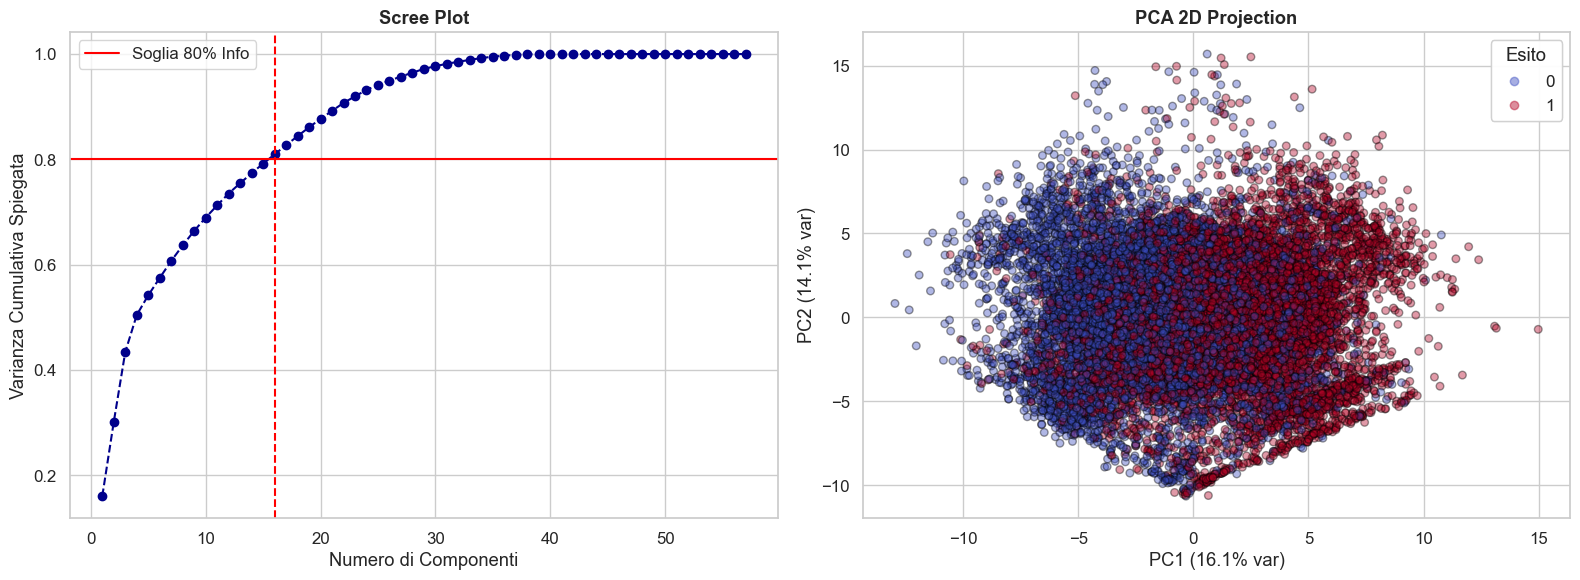


--- RISULTATI PCA ---
1. Riduzione Dimensionale: l'80% della varianza è spiegato dai primi 16 componenti (su 57 variabili).

2. Interpretazione PC1:
WIN_LAST_100_DIFF    0.299925
WIN_LAST_50_DIFF     0.294967
DIFF_ELO             0.285181
WIN_LAST_25_DIFF     0.279249
ATP_POINT_DIFF       0.232206
DIFF_SURF_ELO        0.222681
DIFF_N_GAMES         0.220711
WIN_LAST_5_DIFF      0.196743
p1_win_last_100      0.194826
p1_win_last_50       0.190939
Name: PC1, dtype: float64


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_context("notebook", font_scale=1.1)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("--- ESECUZIONE PCA  ---")

# 1. CARICAMENTO DATI
try:
    df_pca = pd.read_csv("dataset_ml_ready.csv")
    print("Dataset caricato con successo.")
except FileNotFoundError:
    print("Errore: dataset_ml_ready.csv non trovato.")

if 'tourney_date' in df_pca.columns:
    df_pca['tourney_date'] = pd.to_datetime(df_pca['tourney_date'])

# 2. SELEZIONE DELLE FEATURE
# Escludiamo: ID, Nomi, Date e Statistiche POST-match (Ace, DF, Break Points) perchè sono inutili o costituiscono leakage
cols_to_use = [
    # Contesto Match
    'best_of', 'round_num',
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', # Le tue colonne surface
    
    # Player 1 - Fisico e Ranking
    'p1_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 'p1_is_left', 
    'p1_matches_played',
    
    # Player 1 - ELO e Trend
    'p1_elo', 'p1_surface_elo', 'p1_prob_elo', 'p1_h2h',
    'p1_win_last_5', 'p1_win_last_25', 'p1_win_last_50', 'p1_win_last_100',
    'p1_elo_grad_20', 'p1_elo_grad_35', 'p1_elo_grad_50', 'p1_elo_grad_100',

    # Player 2 - Fisico e Ranking
    'p2_rank', 'p2_rank_points', 'p2_age', 'p2_ht', 'p2_is_left', 
    'p2_matches_played',

    # Player 2 - ELO e Trend
    'p2_elo', 'p2_surface_elo', 'p2_h2h',
    'p2_win_last_5', 'p2_win_last_25', 'p2_win_last_50', 'p2_win_last_100',
    'p2_elo_grad_20', 'p2_elo_grad_35', 'p2_elo_grad_50', 'p2_elo_grad_100',

    # Differenziali
    'ATP_RANK_DIFF', 'ATP_POINT_DIFF', 'DIFF_ELO', 'DIFF_N_GAMES',
    'diff_age', 'diff_ht', 'DIFF_SURF_ELO', 'DIFF_H2H',
    'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF',
    'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF'
]

valid_features = [c for c in cols_to_use if c in df_pca.columns]
print(f"Feature totali selezionate: {len(valid_features)}")

# 3. SPLIT CRONOLOGICO (Train < 2023, Test >= 2023)
train_mask = df_pca['tourney_date'] < '2023-01-01'
test_mask = df_pca['tourney_date'] >= '2023-01-01'

X_train = df_pca.loc[train_mask, valid_features]
y_train = df_pca.loc[train_mask, 'target']

X_test = df_pca.loc[test_mask, valid_features]

print(f"Righe Train (2000-2022): {X_train.shape[0]}")
print(f"Righe Test (2023-2024): {X_test.shape[0]}")

# 4. NORMALIZZAZIONE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 5. APPLICAZIONE PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# ==========================================
# VISUALIZZAZIONE RISULTATI
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO A: Scree Plot (Varianza Cumulativa)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_80 = np.argmax(cum_var >= 0.80) + 1 

axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--', color='darkblue')
axes[0].axhline(y=0.80, color='red', linestyle='-', label='Soglia 80% Info')
axes[0].axvline(x=n_80, color='red', linestyle='--')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xlabel('Numero di Componenti')
axes[0].set_ylabel('Varianza Cumulativa Spiegata')
axes[0].legend()
axes[0].grid(True)

# GRAFICO B: PC1 vs PC2 Scatterplot
# Campioniamo 5000 punti casuali per non rendere il grafico illeggibile
if X_train_pca.shape[0] > 35000:
    idx = np.random.choice(X_train_pca.shape[0], 35000, replace=False)
else:
    idx = np.arange(X_train_pca.shape[0])

scatter = axes[1].scatter(
    X_train_pca[idx, 0], 
    X_train_pca[idx, 1], 
    c=y_train.iloc[idx], 
    cmap='coolwarm', alpha=0.4, edgecolor='k', s=30
)
axes[1].set_title('PCA 2D Projection', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Esito")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

# ANALISI TESTUALE
print("\n--- RISULTATI PCA ---")
print(f"1. Riduzione Dimensionale: l'80% della varianza è spiegato dai primi {n_80} componenti (su {len(valid_features)} variabili).")

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(valid_features))], 
    index=valid_features
)
print("\n2. Interpretazione PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

--- ADDESTRAMENTO DECISION TREE (CART) ---
Training su 68844 partite (2000-2022)
Testing su 6009 partite (2023-2024)

ACCURACY SUL TEST SET (2023-24): 64.42%


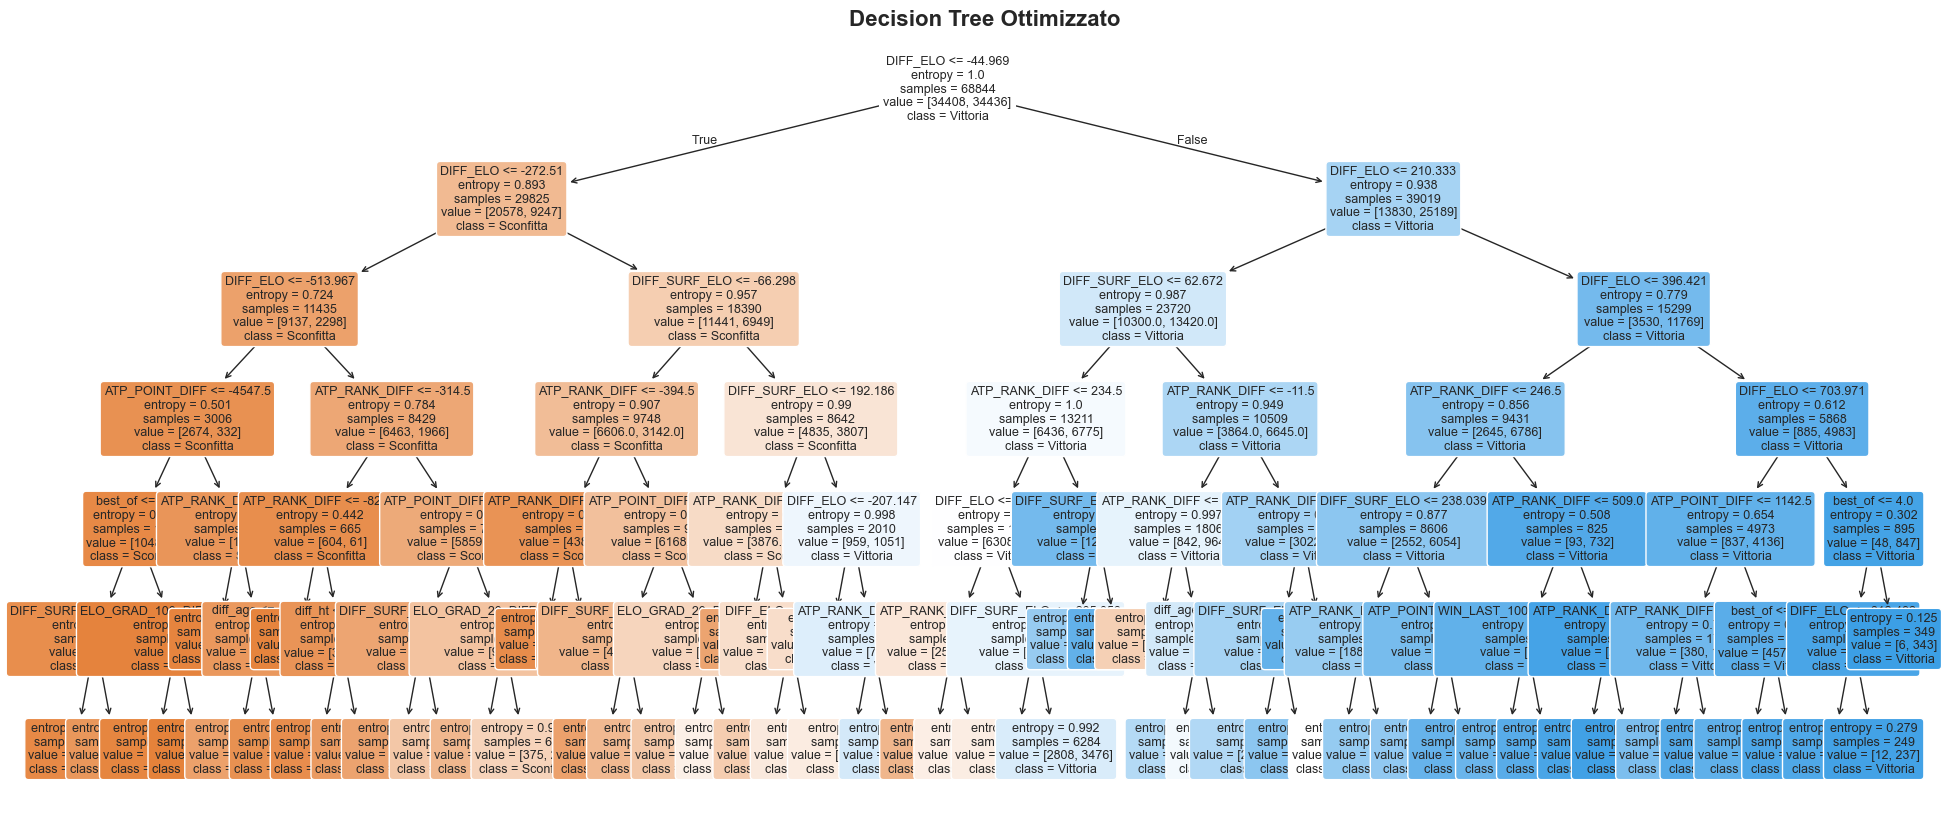


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      3025
           1       0.64      0.63      0.64      2984

    accuracy                           0.64      6009
   macro avg       0.64      0.64      0.64      6009
weighted avg       0.64      0.64      0.64      6009



In [58]:
# ==========================================
# 9. MODELLO 1: DECISION TREE (CART) 
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configurazioni
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("--- ADDESTRAMENTO DECISION TREE (CART) ---")

# 1. CARICAMENTO E PREPARAZIONE
try:
    df_ml = pd.read_csv("dataset_ml_ready.csv")
    df_ml['tourney_date'] = pd.to_datetime(df_ml['tourney_date'])
except:
    print("Errore: Carica prima il file dataset_ml_ready.csv")

# Feature Selection
features = [
    # --- CONTESTO DEL MATCH ---
    'best_of',             
    'round_num',           
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', 
    
    # --- CARATTERISTICHE FISICHE ---
    'diff_age',            
    'diff_ht',             
    'p1_is_left',         
    'p2_is_left',         
    
    # --- RANKING E ELO  ---
    'DIFF_ELO',            
    'DIFF_SURF_ELO',       
    'ATP_RANK_DIFF',       
    'ATP_POINT_DIFF',      
    'DIFF_H2H',            
    
    # --- ESPERIENZA ---
    'DIFF_N_GAMES',        
    
    # --- FORMA RECENTE ---
    'WIN_LAST_5_DIFF',     # Forma brevissimo termine
    'WIN_LAST_25_DIFF',    # Forma breve termine
    'WIN_LAST_50_DIFF',    # Forma medio termine
    'WIN_LAST_100_DIFF',   # Forma lungo termine
    
    # --- TREND DI MIGLIORAMENTO ---
    'ELO_GRAD_20_DIFF',    
    'ELO_GRAD_35_DIFF',    
    'ELO_GRAD_50_DIFF',    
    'ELO_GRAD_100_DIFF'    
]

# 2. SPLIT CRONOLOGICO
# Train: 2000-2022 | Test: 2023-2024
train_mask = df_ml['tourney_date'] < '2023-01-01'
test_mask = df_ml['tourney_date'] >= '2023-01-01'

X_train = df_ml.loc[train_mask, features]
y_train = df_ml.loc[train_mask, 'target']
X_test = df_ml.loc[test_mask, features]
y_test = df_ml.loc[test_mask, 'target']

print(f"Training su {len(X_train)} partite (2000-2022)")
print(f"Testing su {len(X_test)} partite (2023-2024)")

# 3. ADDESTRAMENTO MODELLO
clf_tree = DecisionTreeClassifier(
    criterion='entropy',      # Parametro ottimizzato
    max_depth=6,              # Parametro ottimizzato
    min_samples_leaf=200,     # Parametro ottimizzato
    random_state=42
)

clf_tree.fit(X_train, y_train)

# 4. VALUTAZIONE
y_pred = clf_tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nACCURACY SUL TEST SET (2023-24): {acc:.2%}")

# 5. VISUALIZZAZIONE ALBERO 
plt.figure(figsize=(24, 10))
plot_tree(
    clf_tree, 
    feature_names=features, 
    class_names=['Sconfitta', 'Vittoria'], 
    filled=True, 
    rounded=True, 
    fontsize=9,
    max_depth=6 
)
plt.title(f"Decision Tree Ottimizzato", fontsize=16, fontweight='bold')
plt.show()


# Stampa report testuale
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

--- ADDESTRAMENTO RETE NEURALE (MLP) CON OTTIMIZZAZIONE ---
Dati normalizzati. Avvio Grid Search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

MIGLIORI PARAMETRI: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Miglior Accuracy (durante il training): 68.08%
------------------------------
ACCURACY FINALE SUL TEST SET: 65.30%
------------------------------


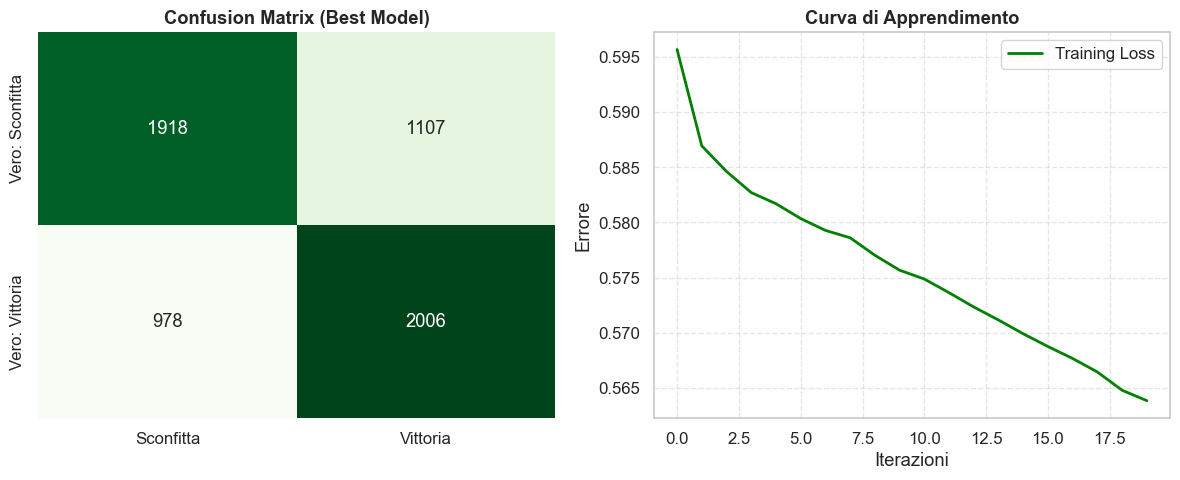

In [59]:
# ==========================================
# 10. MODELLO 2: RETE NEURALE 
# ==========================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- ADDESTRAMENTO RETE NEURALE (MLP) CON OTTIMIZZAZIONE ---")

# 1. PREPARAZIONE FEATURES

# Filtri temporali
train_mask = df_ml['tourney_date'] < '2023-01-01'
test_mask = df_ml['tourney_date'] >= '2023-01-01'

# Creazione matrici X e y
X_train_opt = df_ml.loc[train_mask, cols_to_use].fillna(0)
y_train_opt = df_ml.loc[train_mask, 'target']
X_test_opt = df_ml.loc[test_mask, cols_to_use].fillna(0)
y_test_opt = df_ml.loc[test_mask, 'target']

# 2. SCALING 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_opt)
X_test_scaled = scaler.transform(X_test_opt)

print("Dati normalizzati. Avvio Grid Search...")

# 3. CONFIGURAZIONE GRID SEARCH
param_grid = {
    'hidden_layer_sizes': [(128, 64, 32), (128, 64), (64, 32)], 
    
    'alpha': [0.0001, 0.001, 0.01],  
    
    'activation': ['relu', 'tanh'],  
    
    'learning_rate_init': [0.001]
}

# Modello base
mlp_base = MLPClassifier(
    max_iter=150, 
    early_stopping=True, 
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

# Il "Torneo"
grid_search_mlp = GridSearchCV(
    mlp_base,
    param_grid,
    cv=3,              # 3 round di validazione per ogni modello
    scoring='accuracy',
    n_jobs=-1,         
    verbose=1
)

grid_search_mlp.fit(X_train_scaled, y_train_opt)

# 4. RISULTATI
best_mlp = grid_search_mlp.best_estimator_

print(f"\nMIGLIORI PARAMETRI: {grid_search_mlp.best_params_}")
print(f"Miglior Accuracy (durante il training): {grid_search_mlp.best_score_:.2%}")

# 5. VALUTAZIONE FINALE (TEST 2023-2024)
y_pred_final = best_mlp.predict(X_test_scaled)
acc_final = accuracy_score(y_test_opt, y_pred_final)

print("-" * 30)
print(f"ACCURACY FINALE SUL TEST SET: {acc_final:.2%}")
print("-" * 30)

# 6. GRAFICI
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_opt, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sconfitta', 'Vittoria'],
            yticklabels=['Vero: Sconfitta', 'Vero: Vittoria'])
plt.title(f"Confusion Matrix (Best Model)", fontweight='bold')

# Curva di Loss
plt.subplot(1, 2, 2)
plt.plot(best_mlp.loss_curve_, label='Training Loss', color='green', linewidth=2)
plt.title("Curva di Apprendimento", fontweight='bold')
plt.xlabel("Iterazioni")
plt.ylabel("Errore")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

--- REPORT DI VALUTAZIONE FINALE ---

VALUTAZIONE: DECISION TREE
              precision    recall  f1-score   support

   Sconfitta       0.64      0.66      0.65      3025
    Vittoria       0.64      0.63      0.64      2984

    accuracy                           0.64      6009
   macro avg       0.64      0.64      0.64      6009
weighted avg       0.64      0.64      0.64      6009

ROC AUC Score: 0.7013
Accuracy con Intervallo di Confidenza (95%): 64.42% ± 1.21%
   (Range reale stimato: da 63.21% a 65.63%)

VALUTAZIONE: NEURAL NETWORK
              precision    recall  f1-score   support

   Sconfitta       0.66      0.63      0.65      3025
    Vittoria       0.64      0.67      0.66      2984

    accuracy                           0.65      6009
   macro avg       0.65      0.65      0.65      6009
weighted avg       0.65      0.65      0.65      6009

ROC AUC Score: 0.7195
Accuracy con Intervallo di Confidenza (95%): 65.30% ± 1.20%
   (Range reale stimato: da 64.10% a 66.51%

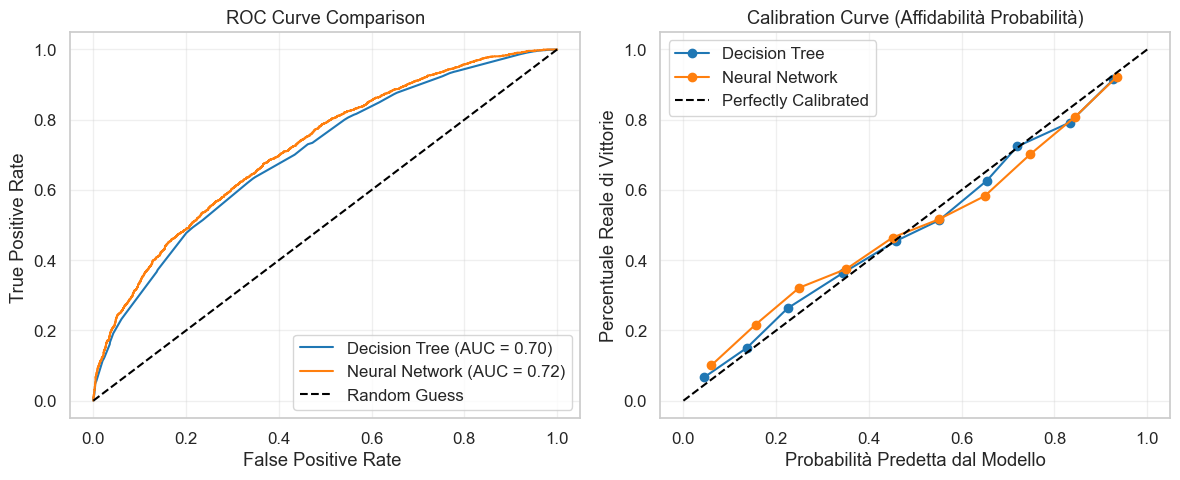

In [61]:
# ==========================================
# EVALUATION & CREDIBILITY
# ==========================================
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

print("--- REPORT DI VALUTAZIONE FINALE ---")

# Definiamo una funzione per calcolare l'Intervallo di Confidenza (95%)
def get_confidence_interval(accuracy, n_samples):
    # Formula standard per proporzioni (
    margin = 1.96 * np.sqrt((accuracy * (1 - accuracy)) / n_samples)
    return margin

models_to_eval = [
    ('Decision Tree', clf_tree, X_test_opt),    
    ('Neural Network', best_mlp, X_test_scaled), 

]

plt.figure(figsize=(12, 5))

# Ciclo su ogni modello
for name, model, X_val in models_to_eval:
    print(f"\nVALUTAZIONE: {name.upper()}")
    
    # 1. Predizioni
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1] # Probabilità di vittoria 
    
    # 2. Metriche Base 
    print(classification_report(y_test_opt, y_pred, target_names=['Sconfitta', 'Vittoria']))
    
    # 3. ROC AUC
    auc = roc_auc_score(y_test_opt, y_prob)
    print(f"ROC AUC Score: {auc:.4f}")
    
    # 4. Confidence Interval (Dal tuo PDF)
    acc = accuracy_score(y_test_opt, y_pred)
    margin = get_confidence_interval(acc, len(y_test_opt))
    print(f"Accuracy con Intervallo di Confidenza (95%): {acc:.2%} ± {margin:.2%}")
    print(f"   (Range reale stimato: da {acc-margin:.2%} a {acc+margin:.2%})")

    # 5. Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test_opt, y_prob)
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    # 6. Plot Calibration Curve 
    prob_true, prob_pred = calibration_curve(y_test_opt, y_prob, n_bins=10)
    plt.subplot(1, 2, 2)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

# --- FINITURA GRAFICI ---

# Grafico ROC
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico Calibrazione
plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Probabilità Predetta dal Modello')
plt.ylabel('Percentuale Reale di Vittorie')
plt.title('Calibration Curve (Affidabilità Probabilità)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()